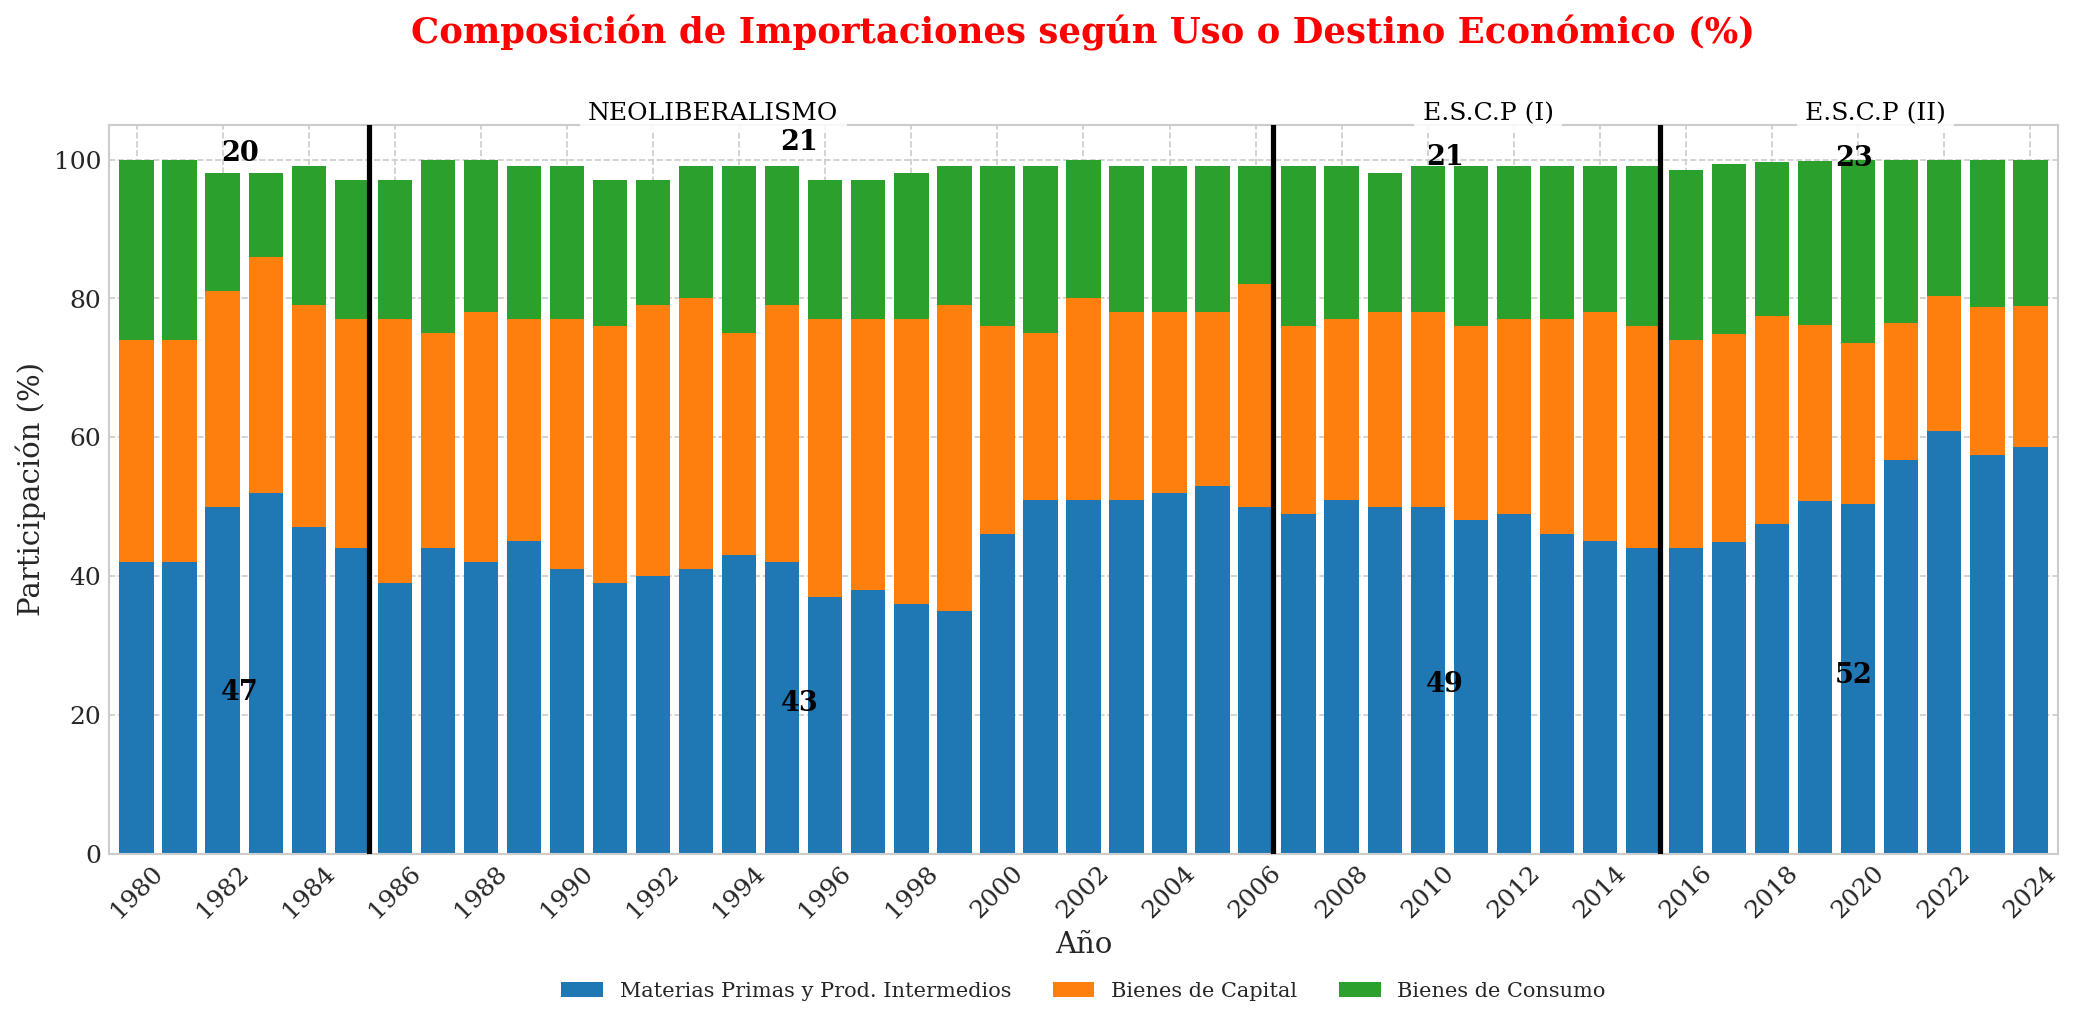

In [1]:
# ═══════════════════════════════════════════════════════════════════
# GRÁFICA DE PERÍODOS ESTRUCTURALES (BARRAS) — COMPOSICIÓN DE IMPORTACIONES
# ═══════════════════════════════════════════════════════════════════
import os
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

from func_auxiliares.graficos_utils import (
    set_style,
    plot_stacked_bar,
    add_hitos_barras,
    add_cycle_means_barras,
    adjust_cycles,
)

from func_auxiliares.config import (
    DB_PATH,
    ASSETS_DIR,
    CYCLES_PERIODOS,
    hitos_v_periodos,
)

# ─────────────────────── 1. CONFIGURACIÓN GENERAL ───────────────────
OUTPUT_DIR = ASSETS_DIR / "serie_completa" / "participacion_composicion_importaciones_uso_destino"
os.makedirs(OUTPUT_DIR, exist_ok=True)
set_style()

# ─────────────────────────── 2. CARGA DE DATOS ──────────────────────
with sqlite3.connect(str(DB_PATH)) as conn:
    df = pd.read_sql(
        "SELECT año, bienes_consumo, materias_primas_productos_intermedios, bienes_capital FROM participacion_composicion_importaciones_uso_destino", 
        conn, 
        index_col="año"
    )

cycles_adj = adjust_cycles(df, CYCLES_PERIODOS)

# Para la gráfica base usaremos data_plot como el DataFrame final.
data_plot = df 

# ──────────────── 3. COMPONENTES Y ESTADÍSTICAS ────────────
componentes = [
    ("materias_primas_productos_intermedios", "Materias Primas y Prod. Intermedios"),
    ("bienes_capital", "Bienes de Capital"),
    ("bienes_consumo", "Bienes de Consumo"),
]
cols = [c for c, _ in componentes]

# Cálculo de estadísticas promedio por ciclo
cycle_stats = {
    name: data_plot.loc[sl, cols].mean().to_dict()
    for name, sl in cycles_adj.items()
}

# ───────────────────── 4. OFFSETS DE POSICIONAMIENTO ────────────────
hitos_offset = {
    1952: (0, 1),
    1985: (0, 1),
    2006: (0, 1),
    2015: (0, 1)
}
hitos_text_x = {
    1952: 12,
    1985: 8,
    2006: 5,
    2015: 5
}

# Offsets manuales para mover las anotaciones de la media de alguna columna
MEAN_OFFSETS_BY_NAME = {
    "INTERVENSIONISMO ESTATAL": {'bienes_consumo': (0.0, 12.0)}, 
    "NEOLIBERALISMO":           {'bienes_consumo': (0.0, 14.5)},
    "E.S.C.P (I)":              {'bienes_consumo': (0.0, 12.0)},
    "E.S.C.P (II)":             {'bienes_consumo': (0.0, 12.0)},
}

# Componentes de las que NO se quiere mostrar el promedio en el gráfico
SKIP_MEANS_BY_NAME = {
    "INTERVENSIONISMO ESTATAL": {'bienes_capital'}, 
    "NEOLIBERALISMO":           {'bienes_capital'},
    "E.S.C.P (I)":              {'bienes_capital'},
    "E.S.C.P (II)":             {'bienes_capital'},
}

# ────────────────────────── 5. PLOT Y ANOTACIONES ─────────────────────────
fig, ax = plot_stacked_bar(
    data_plot, 
    series=componentes,
    title="Composición de Importaciones según Uso o Destino Económico (%)\n",
    legend_ncol=3
)

add_hitos_barras(
    ax, data_plot.index, hitos_v_periodos, hitos_offset, hitos_text_x
)

add_cycle_means_barras(
    ax,
    index=list(data_plot.index),   # secuencia de años
    cycle_slices=cycles_adj,       # nombre → slice
    cycle_stats=cycle_stats,       # nombre → {col: media}
    cols=cols,                     # orden de apilado
    offsets=MEAN_OFFSETS_BY_NAME,  # opcional
    skip=SKIP_MEANS_BY_NAME        # opcional
)

# ────────────────────────── 6. GUARDADO ─────────────────────────────
plt.tight_layout()
out_path = OUTPUT_DIR / "participacion_composicion_importaciones_uso_destino_periodos.png"
plt.savefig(out_path, dpi=300, bbox_inches="tight")
plt.show()
plt.close()
